# 6. Selección de Variables Multi-Versión

Este notebook calcula importancia de variables para **cada versión de target** creada en el notebook 5.

## Enfoque
- Usa datasets mergeados `data/merged_versions/OPERA_COMPLETO_*.xlsx`
- Aplica filtro de adultos (`Edad >= 18`)
- Calcula ranking con **Mutual Information** + **Random Forest Importance**
- Exporta ranking y selección por versión para modelado comparativo

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import warnings

import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from utils.multi_version import run_feature_selection_pipeline
from utils.version_config import ACTIVE_VERSIONS, VERSION_HISTORY

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TOP_N = 80

DATA_DIR = Path("../data")
MERGED_DIR = DATA_DIR / "merged_versions"
FEATURES_DIR = Path("../features")
VERSION_FEATURES_DIR = FEATURES_DIR / "versioned"
VERSION_FEATURES_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_META_PATH = FEATURES_DIR / "variables_seleccionadas.csv"

## 2. Carga de Versiones y Metadatos

In [2]:
print(f"Versiones activas: {ACTIVE_VERSIONS}")
display(pd.DataFrame(VERSION_HISTORY))

selection_artifacts = run_feature_selection_pipeline(
    merged_dir=MERGED_DIR,
    features_meta_path=FEATURES_META_PATH,
    output_dir=VERSION_FEATURES_DIR,
    top_n=TOP_N,
    random_state=RANDOM_STATE,
    active_versions=ACTIVE_VERSIONS,
)

print(f"Versiones detectadas/procesadas: {len(selection_artifacts['versions'])}")
for _, row in selection_artifacts["versions"].iterrows():
    print(f"  - {row['file']}")

if selection_artifacts.get("ignored_versions"):
    print("\nVersiones ignoradas (no activas):")
    for version in selection_artifacts["ignored_versions"]:
        print(f"  - {version}")

print(f"\nVariables base candidatas: {pd.read_csv(FEATURES_META_PATH).shape[0]}")

Versiones activas: ['v1', 'v2', 'v3_sin_liquidos']


,version,threshold,flags_to_use,excluded_flags,apply_cancel_non_medico_rule,export_name,description,executed_on,notes
0,v1,1,RELEVANT_FLAGS,EXCLUDED_FLAGS,True,OPERA_POS_v1.xlsx,Sin agregación (>=1 flag),2026-02-28,Baseline histórico
1,v2,2,RELEVANT_FLAGS,EXCLUDED_FLAGS,True,OPERA_POS_v2.xlsx,Con agregación (>=2 flags),2026-02-28,Baseline histórico
2,v3_sin_liquidos,1,RELEVANT_FLAGS - flag_liquidos,EXCLUDED_FLAGS,True,OPERA_POS_v3_sin_liquidos.xlsx,Sin flag_liquidos (>=1 flag),2026-02-28,Sensibilidad clínica


Sanitización de Features realizada:
   - Originales: 173
   - Mantenidas: 172
   - Eliminadas (constantes): 1
   - Ejemplos eliminados: ['Anestesia previa_intraarticular']
Sanitización de Features realizada:
   - Originales: 173
   - Mantenidas: 172
   - Eliminadas (constantes): 1
   - Ejemplos eliminados: ['Anestesia previa_intraarticular']
Sanitización de Features realizada:
   - Originales: 173
   - Mantenidas: 172
   - Eliminadas (constantes): 1
   - Ejemplos eliminados: ['Anestesia previa_intraarticular']
Versiones detectadas/procesadas: 3
  - OPERA_COMPLETO_v1.xlsx
  - OPERA_COMPLETO_v2.xlsx
  - OPERA_COMPLETO_v3_sin_liquidos.xlsx

Variables base candidatas: 55


## 3. Funciones de Ranking por Versión

In [3]:
rankings_by_version = selection_artifacts["rankings_by_version"]
selected_by_version = selection_artifacts["selected_by_version"]
df_version_summary = selection_artifacts["summary"]
feature_frequency = selection_artifacts["feature_frequency"]
selection_matrix = selection_artifacts["selection_matrix"]
df_export_registry = selection_artifacts["export_registry"]

print("Pipeline de selección ejecutado.")
print(f"Versiones procesadas: {len(df_version_summary)}")
print(f"Features de consenso: {len(selection_artifacts['consensus_features'])}")

Pipeline de selección ejecutado.
Versiones procesadas: 3
Features de consenso: 78


In [4]:
selection_artifacts["versions"]

,version,file
0,v1,OPERA_COMPLETO_v1.xlsx
1,v2,OPERA_COMPLETO_v2.xlsx
2,v3_sin_liquidos,OPERA_COMPLETO_v3_sin_liquidos.xlsx


## 4. Ejecución del Ranking en Todas las Versiones

In [5]:
df_version_summary

,version,rows,target_1_pct,candidate_features,selected_features,missing_features,dropped_constant
0,v1,23387,51.75,172,80,1,1
1,v2,23387,22.87,172,80,1,1
2,v3_sin_liquidos,23387,50.58,172,80,1,1


## 5. Comparación de Features entre Versiones

In [6]:
feature_frequency.head(30)

,Variable,n_versions_selected
0,Abdomen_distension,3
1,Antecedente gastrointestinales_gastritis,3
2,Antecedente gastrointestinales_negativo,3
3,Antecedentes anestésicos,3
4,Antecedentes quirúrgicos Code_G,3
5,Antecedentes quirúrgicos Code_H,3
6,Antecedentes quirúrgicos Code_P,3
7,Condición_vih,3
8,Dx Preoperatorio Code_H,3
9,Dx Preoperatorio Code_K,3


## 6. Matriz de Selección (Feature × Versión)

In [7]:
selection_matrix.head(25)

version,v1,v2,v3_sin_liquidos
Variable,,,
Abdomen_distension,1,1,1
Abdomen_masas,1,0,1
Abdomen_otro,1,0,1
Anestesia previa_conductiva,0,1,1
Anestesia previa_general,1,0,0
Anestesia previa_local,1,0,1
Anestesia previa_peridural,0,1,0
Anestesia previa_sedacion,0,1,0
Anestesia previa_topica,1,0,0


## 7. Exportación de Artefactos por Versión

In [8]:
df_export_registry

,version,ranking_path,selected_path,selected_txt_path,n_selected
0,v1,../features/versioned/v1_variable_ranking.csv,../features/versioned/v1_variables_selected.csv,../features/versioned/v1_selected_features_lis...,80
1,v2,../features/versioned/v2_variable_ranking.csv,../features/versioned/v2_variables_selected.csv,../features/versioned/v2_selected_features_lis...,80
2,v3_sin_liquidos,../features/versioned/v3_sin_liquidos_variable...,../features/versioned/v3_sin_liquidos_variable...,../features/versioned/v3_sin_liquidos_selected...,80


## 8. Exportación de Resúmenes Globales

In [9]:
print("Resumen por versión:", selection_artifacts["summary_path"])
print("Frecuencia de features:", selection_artifacts["frequency_path"])
print("Matriz feature×versión:", selection_artifacts["matrix_path"])
print("Registro de exports:", selection_artifacts["registry_path"])

Resumen por versión: ../features/versioned/summary_versions.csv
Frecuencia de features: ../features/versioned/feature_frequency_across_versions.csv
Matriz feature×versión: ../features/versioned/selection_matrix_across_versions.csv
Registro de exports: ../features/versioned/exports_registry_versions.csv


## 9. Top Features Globales (consenso)

In [10]:
top_global = feature_frequency.sort_values(
    ["n_versions_selected", "Variable"],
    ascending=[False, True],
).reset_index(drop=True)

top_global.head(50)

,Variable,n_versions_selected
0,Abdomen_distension,3
1,Antecedente gastrointestinales_gastritis,3
2,Antecedente gastrointestinales_negativo,3
3,Antecedentes anestésicos,3
4,Antecedentes quirúrgicos Code_G,3
5,Antecedentes quirúrgicos Code_H,3
6,Antecedentes quirúrgicos Code_P,3
7,Condición_vih,3
8,Dx Preoperatorio Code_H,3
9,Dx Preoperatorio Code_K,3


## 10. Vista rápida por versión

In [11]:
version_to_inspect = df_version_summary.iloc[0]["version"]
print(f"Versión seleccionada: {version_to_inspect}")

rankings_by_version[version_to_inspect].head(25)

Versión seleccionada: v1


,Variable,MI_Score,RF_Importance,MI_Norm,RF_Norm,Combined_Score
0,Tipo de anestesia propuesta_sedacion,0.026555,0.141886,0.430131,1.000000,0.715066
1,score_proc_moderate_severity,0.061738,0.027680,1.000000,0.195087,0.597543
2,score_proc_critical,0.058536,0.033181,0.948145,0.233856,0.591001
3,score_proc_high_severity,0.058522,0.032457,0.947914,0.228756,0.588335
4,score_proc_medium_severity,0.059708,0.028766,0.967119,0.202742,0.584931
5,score_proc_low_severity,0.056553,0.029990,0.916023,0.211365,0.563694
6,score_dx_high_severity,0.050575,0.021074,0.819193,0.148524,0.483859
7,score_dx_critical,0.047876,0.020552,0.775470,0.144847,0.460158
8,score_dx_low_severity,0.044615,0.020214,0.722657,0.142468,0.432563
9,score_dx_moderate_severity,0.043920,0.021471,0.711392,0.151324,0.431358


## 11. Distribución de cantidad de features seleccionadas

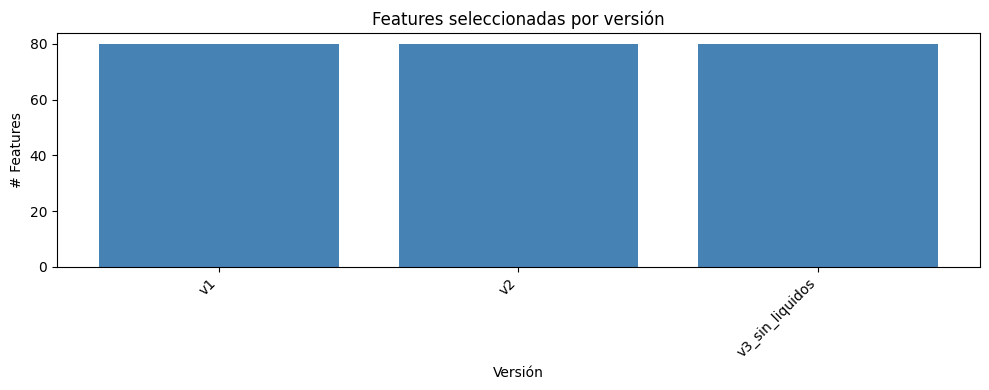

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(df_version_summary["version"], df_version_summary["selected_features"], color="steelblue")
plt.title("Features seleccionadas por versión")
plt.xlabel("Versión")
plt.ylabel("# Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
df_version_summary[["version", "rows", "target_1_pct", "candidate_features", "selected_features"]]

,version,rows,target_1_pct,candidate_features,selected_features
0,v1,23387,51.75,172,80
1,v2,23387,22.87,172,80
2,v3_sin_liquidos,23387,50.58,172,80


## 12. Selección de Consenso (opcional)

In [14]:
min_versions = max(1, int(np.ceil(len(df_version_summary) * 0.5)))
consensus_features = selection_artifacts["consensus_features"]

print(f"Features de consenso (>= {min_versions} versiones): {len(consensus_features)}")
print(f"Archivo: {selection_artifacts['consensus_path']}")

Features de consenso (>= 2 versiones): 78
Archivo: ../features/versioned/consensus_selected_features_list.txt


## 13. Estado Final

In [15]:
print("=" * 90)
print("PIPELINE DE SELECCIÓN MULTI-VERSIÓN COMPLETADO")
print("=" * 90)
print(f"Versiones procesadas: {len(df_version_summary)}")
print(f"Carpeta de salida: {VERSION_FEATURES_DIR}")
print("\nArchivos clave:")
print("- summary_versions.csv")
print("- exports_registry_versions.csv")
print("- <version>_variable_ranking.csv")
print("- <version>_selected_features_list.txt")
print("- consensus_selected_features_list.txt")

PIPELINE DE SELECCIÓN MULTI-VERSIÓN COMPLETADO
Versiones procesadas: 3
Carpeta de salida: ../features/versioned

Archivos clave:
- summary_versions.csv
- exports_registry_versions.csv
- <version>_variable_ranking.csv
- <version>_selected_features_list.txt
- consensus_selected_features_list.txt
